In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import accuracy_score, roc_curve, precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.metrics import auc as auc_metric
import warnings
import os
import random
warnings.filterwarnings('ignore')

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_df = pd.read_csv('data/survey lung cancer.csv')
valid_df = pd.read_csv('data/cancer patient data sets.csv')

feature_mapping = {}
if 'Gender' in valid_df.columns:
    feature_mapping['Gender'] = 'GENDER'
if 'Age' in valid_df.columns:
    feature_mapping['Age'] = 'AGE'
if 'Smoking' in valid_df.columns:
    feature_mapping['Smoking'] = 'SMOKING'
if 'Alcohol usé' in valid_df.columns:
    feature_mapping['Alcohol usé'] = 'ALCOHOL_CONSUMING'
if 'Coughing' in valid_df.columns:
    feature_mapping['Coughing'] = 'COUGHING'
if 'Shortness of Breath' in valid_df.columns:
    feature_mapping['Shortness of Breath'] = 'SHORTNESS_OF_BREATH'
elif 'Shortness' in valid_df.columns:
    feature_mapping['Shortness'] = 'SHORTNESS_OF_BREATH'
if 'Chest Pain' in valid_df.columns:
    feature_mapping['Chest Pain'] = 'CHEST_PAIN'
if 'Wheezing' in valid_df.columns:
    feature_mapping['Wheezing'] = 'WHEEZING'

train_features = []
if 'GENDER' in train_df.columns:
    train_features.append('GENDER')
if 'AGE' in train_df.columns:
    train_features.append('AGE')
if 'SMOKING' in train_df.columns:
    train_features.append('SMOKING')
if 'ALCOHOL CONSUMING' in train_df.columns:
    train_features.append('ALCOHOL CONSUMING')
if 'COUGHING' in train_df.columns:
    train_features.append('COUGHING')
if 'SHORTNESS OF BREATH' in train_df.columns:
    train_features.append('SHORTNESS OF BREATH')
if 'CHEST PAIN' in train_df.columns:
    train_features.append('CHEST PAIN')
if 'WHEEZING' in train_df.columns:
    train_features.append('WHEEZING')

rename_dict = {}
if 'ALCOHOL CONSUMING' in train_df.columns:
    rename_dict['ALCOHOL CONSUMING'] = 'ALCOHOL_CONSUMING'
if 'SHORTNESS OF BREATH' in train_df.columns:
    rename_dict['SHORTNESS OF BREATH'] = 'SHORTNESS_OF_BREATH'
if 'CHEST PAIN' in train_df.columns:
    rename_dict['CHEST PAIN'] = 'CHEST_PAIN'

train_df_processed = train_df.rename(columns=rename_dict)
train_features_processed = [rename_dict.get(f, f) for f in train_features]

valid_df_processed = valid_df.rename(columns=feature_mapping)
valid_df_processed['LUNG_CANCER'] = valid_df_processed['Level'].map({'High': 1, 'Medium': 1, 'Low': 0})

common_features = list(set(train_features_processed) & set(feature_mapping.values()))
train_df_common = train_df_processed[common_features + ['LUNG_CANCER']]
valid_df_common = valid_df_processed[common_features + ['LUNG_CANCER']]

if train_df_common['LUNG_CANCER'].dtype == 'object':
    train_df_common['LUNG_CANCER'] = train_df_common['LUNG_CANCER'].map({'YES': 1, 'NO': 0})
train_df_common['LUNG_CANCER'] = train_df_common['LUNG_CANCER'].astype(int)
valid_df_common['LUNG_CANCER'] = valid_df_common['LUNG_CANCER'].astype(int)

train_df_common['GENDER'] = train_df_common['GENDER'].astype(str)
valid_df_common['GENDER'] = valid_df_common['GENDER'].astype(str)
if set(valid_df_common['GENDER'].unique()) == {'1', '2'}:
    valid_df_common['GENDER'] = valid_df_common['GENDER'].map({'1': 'M', '2': 'F'})

combined_df = pd.concat([train_df_common, valid_df_common], ignore_index=True)

X = combined_df[common_features]
y = combined_df['LUNG_CANCER'].astype(int)

if 'GENDER' in X.columns:
    X['GENDER'] = X['GENDER'].astype(str)
    X['GENDER'] = X['GENDER'].map({'M': 'M', 'F': 'F', '1': 'M', '2': 'F', 'Male': 'M', 'Female': 'F'}).fillna(X['GENDER'])
    le = LabelEncoder()
    X['GENDER'] = le.fit_transform(X['GENDER'])

# ========== 添加多项式特征（2次，含交互项） ==========
print("The number of original features:", X.shape[1])
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X)
print("Polynomial characteristic number:", X_poly.shape[1])
feature_names_poly = poly.get_feature_names_out(X.columns)
X = pd.DataFrame(X_poly, columns=feature_names_poly)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor_cpu = torch.FloatTensor(X_train_scaled.astype(np.float32))
y_train_tensor_cpu = torch.FloatTensor(y_train.values.astype(np.float32)).reshape(-1, 1)
X_test_tensor_cpu = torch.FloatTensor(X_test_scaled.astype(np.float32))
y_test_tensor_cpu = torch.FloatTensor(y_test.values.astype(np.float32)).reshape(-1, 1)

X_train_tensor = X_train_tensor_cpu.to(device)
y_train_tensor = y_train_tensor_cpu.to(device)
X_test_tensor = X_test_tensor_cpu.to(device)
y_test_tensor = y_test_tensor_cpu.to(device)

train_dataset = TensorDataset(X_train_tensor_cpu, y_train_tensor_cpu)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

class AttentionModule(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.attention_weights = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, 1),
            nn.Softmax(dim=1)
        )
    def forward(self, x):
        att = self.attention_weights(x)
        return x * att, att

class CNNFeatureExtractor(nn.Module):
    def __init__(self, input_dim, output_dim=128):
        super().__init__()
        self.conv1d = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(64, output_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1d(x)
        x = x.squeeze(-1)
        return self.fc(x)

class EnhancedTemporalCausalNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_treatments=3, sequence_length=20,
                 use_attention=True, use_cnn=True, use_lstm=True):
        super().__init__()
        self.input_dim = input_dim
        self.sequence_length = sequence_length
        self.num_treatments = num_treatments
        self.use_attention = use_attention
        self.use_cnn = use_cnn
        self.use_lstm = use_lstm

        if use_cnn:
            self.cnn_extractor = CNNFeatureExtractor(input_dim, hidden_dim // 2)
            cnn_out = hidden_dim // 2
        else:
            cnn_out = 0

        if use_attention:
            self.attention = AttentionModule(input_dim)

        state_in = input_dim
        if use_attention:
            state_in += input_dim
        if use_cnn:
            state_in += cnn_out

        if use_lstm:
            self.state_encoder = nn.LSTM(state_in, hidden_dim, batch_first=True, dropout=0.3)
        else:
            self.state_encoder = nn.Sequential(
                nn.Linear(state_in, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(0.3)
            )

        self.treatment_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3)
        )

        self.causal_mechanism = nn.Sequential(
            nn.Linear(hidden_dim + num_treatments, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        self.propensity_net = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_treatments),
            nn.Softmax(dim=1)
        )

    def forward(self, x, treatment=None, return_components=False):
        if len(x.shape) == 1:
            x = x.unsqueeze(0)
        orig = x.clone()

        if self.use_attention:
            att_x, _ = self.attention(x)
            x = torch.cat([orig, att_x], dim=1)

        if self.use_cnn:
            cnn_feat = self.cnn_extractor(orig)
            x = torch.cat([x, cnn_feat], dim=1) if self.use_attention else torch.cat([orig, cnn_feat], dim=1)

        if self.use_lstm:
            if len(x.shape) == 2:
                b, _ = x.shape
                x = x.unsqueeze(1).repeat(1, self.sequence_length, 1)
                x = x + torch.randn_like(x) * 0.01
            encoded, (h, _) = self.state_encoder(x)
            patient = h[-1]
        else:
            patient = self.state_encoder(x)

        state_enc = self.treatment_encoder(patient)

        if treatment is None:
            return self.propensity_net(patient)
        else:
            if len(treatment.shape) == 1:
                treatment = treatment.unsqueeze(0)
            effect = self.causal_mechanism(torch.cat([state_enc, treatment], dim=1))
            effect = torch.clamp(effect, 1e-7, 1-1e-7)
            if return_components:
                return {'treatment_effect': effect, 'patient_representation': patient, 'state_encoded': state_enc}
            return effect

    def estimate_ate(self, x, treatments=None):
        if len(x.shape) == 1:
            x = x.unsqueeze(0)
        b = x.shape[0]
        d = x.device
        if treatments is None:
            treatments = torch.eye(self.num_treatments, device=d)
        outs = []
        for t in treatments:
            t_exp = t.unsqueeze(0).repeat(b, 1)
            outs.append(self.forward(x, t_exp))
        return torch.stack(outs, dim=1)

def train_model(model, train_loader, X_test_tensor, y_test_tensor, epochs=300, patience=150):
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=30, verbose=False)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    best_test_acc = 0.0
    best_state = None
    counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            bs = bx.shape[0]
            treat = torch.randint(0, 3, (bs,), device=device)
            treat_onehot = torch.eye(3, device=device)[treat]
            out_dict = model(bx, treat_onehot, return_components=True)
            pred = out_dict['treatment_effect']
            loss = nn.BCELoss()(pred, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            pred_bin = (pred > 0.5).float()
            total += by.size(0)
            correct += (pred_bin == by).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        with torch.no_grad():
            test_treat = torch.randint(0, 3, (X_test_tensor.shape[0],), device=device)
            test_treat_onehot = torch.eye(3, device=device)[test_treat]
            test_out = model(X_test_tensor, test_treat_onehot, return_components=True)
            test_pred = test_out['treatment_effect']
            test_loss = nn.BCELoss()(test_pred, y_test_tensor).item()
            test_acc = ((test_pred > 0.5).float() == y_test_tensor).float().mean().item()

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        scheduler.step(test_loss)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_state = model.state_dict().copy()
            counter = 0
        else:
            counter += 1
        if counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, test_losses, train_accs, test_accs

def evaluate_and_save_single(model, model_name, run_idx, save_base_dir='saved_figures'):
    """单次运行评估，保存预测概率和标签，用于后续平均ROC/PR"""
    save_dir = os.path.join(save_base_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)
    
    model.eval()
    with torch.no_grad():
        fixed_treat = torch.tensor([1., 0., 0.], device=device)
        treat_batch = fixed_treat.unsqueeze(0).repeat(X_test_tensor.shape[0], 1)
        pred_proba = model(X_test_tensor, treat_batch).cpu().numpy().flatten()
    y_true = y_test.values.flatten().astype(int)
    
    np.savez(os.path.join(save_dir, f'run{run_idx}_predictions.npz'), 
             pred_proba=pred_proba, y_true=y_true)
    return pred_proba, y_true

def plot_average_curves(model_name, runs_data, save_base_dir='saved_figures'):

    save_dir = os.path.join(save_base_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)
    
    n_runs = len(runs_data)
    min_epochs = min(len(d['train_losses']) for d in runs_data)
    
    train_losses_stack = np.array([d['train_losses'][:min_epochs] for d in runs_data])
    test_losses_stack = np.array([d['test_losses'][:min_epochs] for d in runs_data])
    train_accs_stack = np.array([d['train_accs'][:min_epochs] for d in runs_data])
    test_accs_stack = np.array([d['test_accs'][:min_epochs] for d in runs_data])
    
    train_loss_mean = train_losses_stack.mean(axis=0)
    train_loss_std = train_losses_stack.std(axis=0)
    test_loss_mean = test_losses_stack.mean(axis=0)
    test_loss_std = test_losses_stack.std(axis=0)
    train_acc_mean = train_accs_stack.mean(axis=0)
    train_acc_std = train_accs_stack.std(axis=0)
    test_acc_mean = test_accs_stack.mean(axis=0)
    test_acc_std = test_accs_stack.std(axis=0)
    
    final_train_loss = train_loss_mean[-1]
    final_test_loss = test_loss_mean[-1]
    final_train_acc = train_acc_mean[-1]
    final_test_acc = test_acc_mean[-1]
    
    epochs = range(1, min_epochs + 1)
    
    # 1.Loss
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train_loss_mean, label=f'Training Loss (final: {final_train_loss:.4f})', linewidth=2, color='blue')
    plt.fill_between(epochs, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2, color='blue')
    plt.plot(epochs, test_loss_mean, label=f'Test Loss (final: {final_test_loss:.4f})', linewidth=2, color='red')
    plt.fill_between(epochs, test_loss_mean - test_loss_std, test_loss_mean + test_loss_std, alpha=0.2, color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Average Loss Curve (over {n_runs} runs)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'avg_loss_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2.Accuracy 
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train_acc_mean, label=f'Training Accuracy (final: {final_train_acc:.4f})', linewidth=2, color='blue')
    plt.fill_between(epochs, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.2, color='blue')
    plt.plot(epochs, test_acc_mean, label=f'Test Accuracy (final: {final_test_acc:.4f})', linewidth=2, color='red')
    plt.fill_between(epochs, test_acc_mean - test_acc_std, test_acc_mean + test_acc_std, alpha=0.2, color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Average Accuracy Curve (over {n_runs} runs)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'avg_accuracy_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3.ROC
    auc_values = []
    for i in range(n_runs):
        pred_file = os.path.join(save_dir, f'run{i}_predictions.npz')
        if os.path.exists(pred_file):
            data = np.load(pred_file)
            pred_proba = data['pred_proba']
            y_true = data['y_true']
            fpr, tpr, _ = roc_curve(y_true, pred_proba)
            auc_val = auc_metric(fpr, tpr)
            auc_values.append(auc_val)
    auc_mean = np.mean(auc_values)
    auc_std = np.std(auc_values)
    
    first_data = np.load(os.path.join(save_dir, 'run0_predictions.npz'))
    pred_proba_first = first_data['pred_proba']
    y_true_first = first_data['y_true']
    fpr_first, tpr_first, _ = roc_curve(y_true_first, pred_proba_first)
    
    plt.figure(figsize=(6,6))
    plt.plot(fpr_first, tpr_first, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {auc_mean:.3f} ± {auc_std:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve (over {n_runs} runs)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'roc_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4.PR
    ap_values = []
    for i in range(n_runs):
        pred_file = os.path.join(save_dir, f'run{i}_predictions.npz')
        if os.path.exists(pred_file):
            data = np.load(pred_file)
            pred_proba = data['pred_proba']
            y_true = data['y_true']
            ap_val = average_precision_score(y_true, pred_proba)
            ap_values.append(ap_val)
    ap_mean = np.mean(ap_values)
    ap_std = np.std(ap_values)
    
    precision_first, recall_first, _ = precision_recall_curve(y_true_first, pred_proba_first)
    
    plt.figure(figsize=(6,6))
    plt.plot(recall_first, precision_first, color='green', lw=2,
             label=f'PR curve (AP = {ap_mean:.3f} ± {ap_std:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - Precision-Recall Curve (over {n_runs} runs)')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, 'pr_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5.confusion matrix
    y_pred_first = (pred_proba_first > 0.5).astype(int)
    cm = confusion_matrix(y_true_first, y_pred_first)
    acc_first = accuracy_score(y_true_first, y_pred_first)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Cancer', 'Cancer'],
                yticklabels=['No Cancer', 'Cancer'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} - Confusion Matrix (first run, Acc={acc_first:.4f})')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n=== {model_name} Performance Summary (over {n_runs} runs) ===")
    print(f"Test Accuracy: {final_test_acc:.4f} ± {test_acc_std[-1]:.4f}")
    print(f"AUC-ROC: {auc_mean:.4f} ± {auc_std:.4f}")
    print(f"AP: {ap_mean:.4f} ± {ap_std:.4f}")

Using device: cuda
The number of original features: 6
Polynomial characteristic number: 27



=== Running Baseline (3 runs) ===


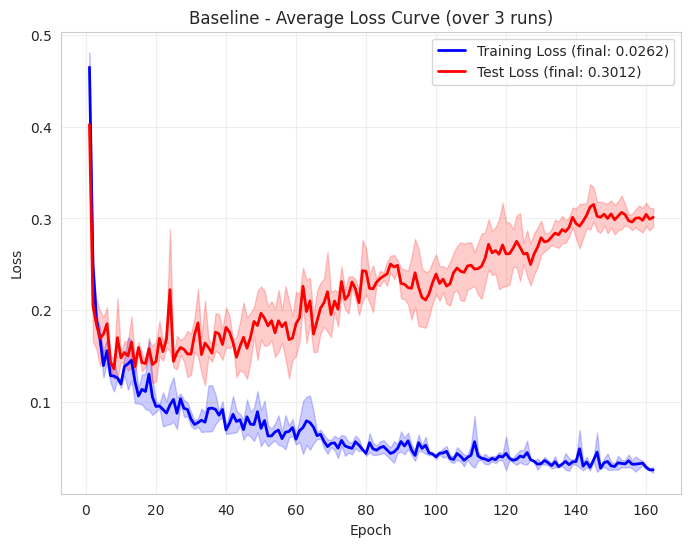

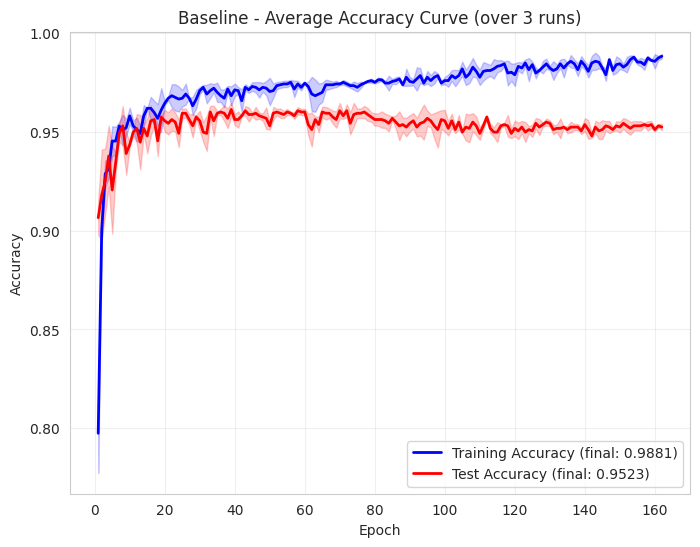

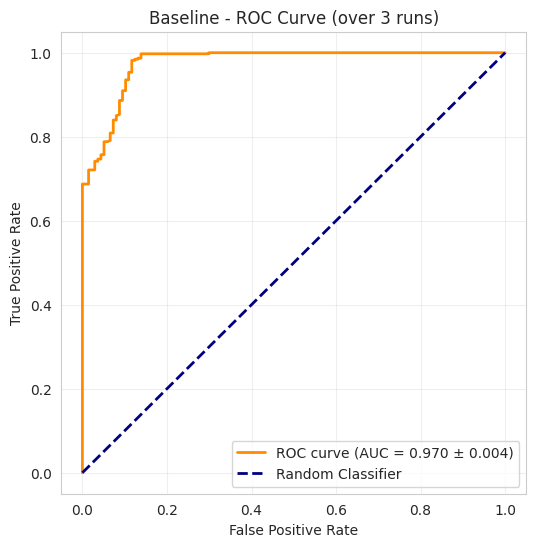

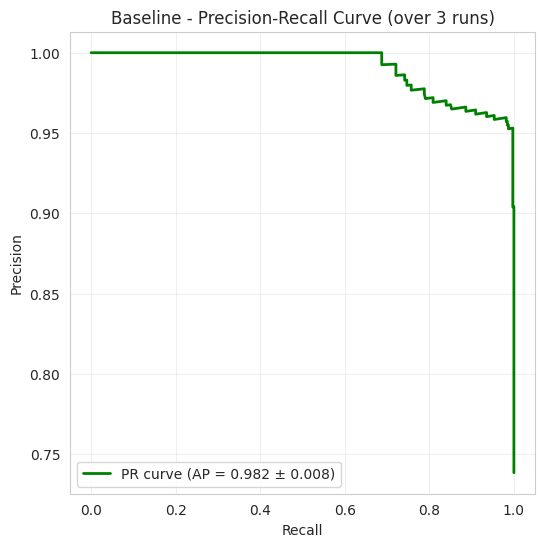

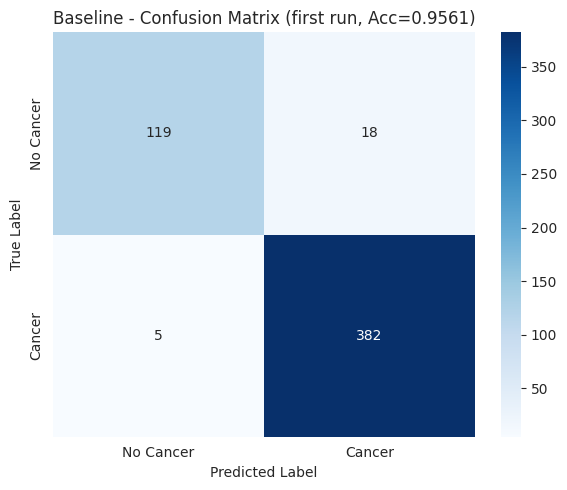


=== Baseline Performance Summary (over 3 runs) ===
Test Accuracy: 0.9523 ± 0.0016
AUC-ROC: 0.9704 ± 0.0042
AP: 0.9817 ± 0.0076


In [2]:
# 1：Baseline
model_name = "Baseline"
print(f"\n=== Running {model_name} (3 runs) ===")

runs_data = []
for run in range(3):
    seed_run = 42 + run
    torch.manual_seed(seed_run)
    np.random.seed(seed_run)
    random.seed(seed_run)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_run)
    
    model = EnhancedTemporalCausalNetwork(
        input_dim=X_train_scaled.shape[1],
        hidden_dim=256,
        num_treatments=3,
        sequence_length=20,
        use_attention=True,
        use_cnn=True,
        use_lstm=True
    ).to(device)
    
    model, train_losses, test_losses, train_accs, test_accs = train_model(
        model, train_loader, X_test_tensor, y_test_tensor,
        epochs=300, patience=150
    )
    
    evaluate_and_save_single(model, model_name, run)
    
    runs_data.append({
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs
    })
    torch.cuda.empty_cache()

plot_average_curves(model_name, runs_data)